<a href="https://colab.research.google.com/github/shaikharaina/Storm-/blob/main/Rahat_NOAA_Storm_Inferencing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
#load the model
import pickle

model_name = '/content/drive/MyDrive/RP_Training_Tabular/Artifacts/best_model.pkl'
file_name = open(model_name, 'rb')
final_model = pickle.load(file_name)
print("Model is loaded")

Model is loaded


In [4]:
import pandas as pd
#read the data file
test_data = pd.read_csv('/content/drive/MyDrive/RP_Training_Tabular/Artifacts/test.csv')
test_data.head()

,MAGNITUDE,TOR_F_SCALE_NUM,TOR_LENGTH,TOR_WIDTH,BEGIN_LAT,BEGIN_LON,DURATION_SECONDS,IS_NIGHT,EVENT_GROUP_Convective_Severe,EVENT_GROUP_Heat_Drought,EVENT_GROUP_Hydrological,EVENT_GROUP_Marine,EVENT_GROUP_Other,EVENT_GROUP_Winter,HAS_DAMAGE
0,0.00,1.0,15.8,33.0,34.43,-102.58,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.00,-1.0,0.0,0.0,41.42,-80.38,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,1.75,-1.0,0.0,0.0,42.32,-95.27,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,0.00,2.0,1.0,27.0,26.98,-82.00,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.75,-1.0,0.0,0.0,41.98,-100.58,0.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
LABEL_COLUMN = "HAS_DAMAGE"

In [6]:
# label catrogories
label_cat = list(test_data[LABEL_COLUMN].unique())
label_cat.sort()

In [7]:
#label count
test_data[LABEL_COLUMN].value_counts()

,count
HAS_DAMAGE,
0,32700
1,5348


In [8]:
test_data[LABEL_COLUMN] = pd.factorize(test_data[LABEL_COLUMN], sort = True)[0]

In [9]:
#labels encoding
#first saved labels for confusion matrix axis
labels = test_data[LABEL_COLUMN].unique()
labels.sort()
print(labels)

[0 1]


In [10]:
import numpy as np

#separating the true labels for the evaluations
y_true = np.array(test_data[LABEL_COLUMN].to_list())

In [11]:
#getting predictions data
test_data_list = test_data.iloc[:,:-1].values

y_pred = []

for row_data in test_data_list:
  predictions = final_model.predict(np.array([row_data]))
  y_pred.append(int(predictions[0]))

print("Predictions: {}".format(y_pred))

Predictions: [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_true, y_pred, labels):
    # Compute normalized confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # Convert to percentages
    cm_percentage = cm * 100

    # Create annotations for confusion matrix values with the percentage sign
    annotations = np.array([[f'{val:.2f}%' for val in row] for row in cm_percentage])

    # Plot the confusion matrix
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm_percentage, annot=annotations, fmt='', cmap="Blues",
                xticklabels=labels, yticklabels=labels)

    plt.title("Normalized Confusion Matrix")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

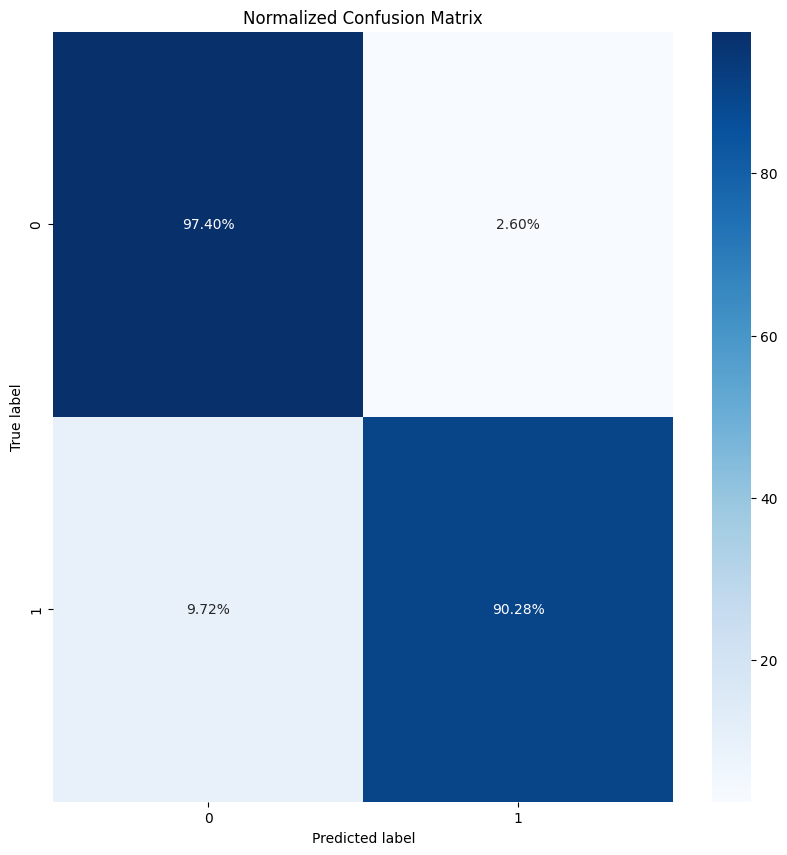

In [13]:
#getting evaulations
plot_confusion_matrix(y_true, y_pred, label_cat)

In [15]:
#classification reports
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     32700
           1       0.85      0.90      0.88      5348

    accuracy                           0.96     38048
   macro avg       0.92      0.94      0.93     38048
weighted avg       0.97      0.96      0.96     38048

